# retinal-cvd-causal-uq — Colab Training Notebook
**Blessing Asare | 2026**

> ⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU`

| # | Cell | Description |
|---|-------|-------------|
| 1 | GPU check | Verify GPU and VRAM |
| 2 | Mount Drive | Extract project from Google Drive |
| 3 | Install deps | scikit-image, statsmodels, pyyaml |
| 4 | DRIVE dataset | Upload instructions + extraction |
| 5 | Train U-Net | Bayesian U-Net on DRIVE ground-truth masks (~8 min on T4) |
| 5b | Calibrate threshold | Dice-optimal vessel_threshold from DRIVE validation (replaces the hand-picked 0.5 default) |
| 6 | Kaggle API | Credentials for RFMiD download (via a hidden runtime prompt, never hardcoded) |
| 7 | Download RFMiD | 1,920 fundus images + labels (Training, Validation, Testing all fetched) |
| 8 | Configure | Paths, checkpoint, mediators, official split paths |
| 9 | **Stage 1** | Segmentation: apply DRIVE-trained U-Net to RFMiD + uncertainty maps |
| 10 | **Stage 2** | Biomarkers: extract 10 vascular features |
| 11 | **Stage 3** | Causal analysis: mediation NDE/NIE + causal forest + non-circular robustness check |
| 12 | **Stage 4** | Conformal UQ: coverage-guaranteed intervals + AUROC/F1/class-conditional coverage |
| 13 | Plots | Results figures |
| 14 | Summary | Print final metrics |
| 15-18 | Official Test-Set Eval | Held-out replication of Stages 1-4 on RFMiD's official 640-image Test split (not a 5th pipeline stage -- see markdown cell above it) |
| 19 | Save | Push outputs to Google Drive |

The paper's pipeline is Stages 1-4 (cells 9-12) only. Everything else
here is setup, calibration, plotting, or the held-out replication check.

**What changed:** Cell 5 trains the U-Net on real DRIVE vessel annotations
instead of pseudo-labels; Cell 9 loads that checkpoint automatically.
Cell 5b calibrates `vessel_threshold` against DRIVE validation instead of
using an uncalibrated 0.5 default. Cells 11-12 add a mediator-circularity
robustness check and classifier discrimination/class-conditional coverage
metrics. Cells 15-18 add genuinely held-out evaluation on RFMiD's official
Test split, not just an internal re-split of the Training set.

In [1]:
# Cell 1: Verify GPU
!nvidia-smi
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError('No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

Sat Jul 25 22:06:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Cell 2: Mount Drive & extract project
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ZIP = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq.zip'
PROJ_DIR    = '/content/retinal-cvd-causal-uq'
DRIVE_OUT   = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq'

import zipfile, os, sys
if not os.path.exists(PROJ_DIR):
    print('Extracting project...')
    with zipfile.ZipFile(PROJECT_ZIP) as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Project already extracted — skipping.')

os.chdir(PROJ_DIR)
sys.path.insert(0, PROJ_DIR)
!ls

Mounted at /content/drive
Extracting project...
Done.
CITATION.cff  data     notebooks  README.md	    scripts   src
configs       LICENSE  outputs	  requirements.txt  setup.py  tests


In [3]:
# Cell 3: Install dependencies
!pip install -q scikit-image statsmodels pyyaml kagglehub
print('Installation complete.')

Installation complete.


## Stage 4 — DRIVE Dataset

**Before running Cell 4**, upload `DRIVE_datasets.zip` to your Google Drive:
```
My Drive / Research Works / DRIVE_datasets.zip
```
The zip should contain `training.zip` and `test.zip` (standard DRIVE nested-zip
from grand-challenge.org).

The DRIVE training set has **20 fundus images with human-annotated vessel masks**.
Cell 5 trains the Bayesian U-Net on those, replacing the old pseudo-label approach.

In [4]:
# Cell 4: Extract DRIVE dataset
import zipfile, io, os

DRIVE_ZIP = '/content/drive/MyDrive/Research Works/DRIVE_datasets.zip'  # ← edit if needed
DRIVE_DIR = '/content/retinal-cvd-causal-uq/data/DRIVE'
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f'Extracting {DRIVE_ZIP} ...')
with zipfile.ZipFile(DRIVE_ZIP, 'r') as outer:
    for inner_name in ('training.zip', 'test.zip'):
        data = outer.read(inner_name)
        with zipfile.ZipFile(io.BytesIO(data)) as inner:
            inner.extractall(DRIVE_DIR)
            n = len([f for f in inner.namelist() if not f.endswith('/')])
            print(f'  {inner_name} → {n} files')

train_imgs  = os.listdir(f'{DRIVE_DIR}/training/images')
train_masks = os.listdir(f'{DRIVE_DIR}/training/1st_manual')
test_imgs   = os.listdir(f'{DRIVE_DIR}/test/images')
print(f'\nTraining : {len(train_imgs)} images, {len(train_masks)} manual masks')
print(f'Test     : {len(test_imgs)} images (no public masks)')
print('DRIVE extraction complete ✓')

Extracting /content/drive/MyDrive/Research Works/DRIVE_datasets.zip ...
  training.zip → 60 files
  test.zip → 40 files

Training : 20 images, 20 manual masks
Test     : 20 images (no public masks)
DRIVE extraction complete ✓


In [5]:
# Cell 5: Train Bayesian U-Net on DRIVE
#
# DRIVEDataset is defined inline — works even if the project zip does not
# contain src/data/drive_dataset.py.
# 16 images for training, 4 for validation.
# Loss = FOV-masked BCE + Dice + KL/N
# Saves best checkpoint (highest val AUROC) to outputs/checkpoints/drive_unet.pt
# Expected time: ~8 min on T4, ~3 min on A100.

import os, random, numpy as np, torch, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from skimage.exposure import equalize_adapthist
from sklearn.metrics import roc_auc_score, f1_score
from src.models.bayesian_unet import BayesianUNet

# ── inline DRIVEDataset ───────────────────────────────────────────────────────

def _clahe_green(img_uint8):
    img = img_uint8.astype(np.float32) / 255.0
    img[:, :, 1] = equalize_adapthist(img[:, :, 1], clip_limit=0.03)
    return img

def _load_gif_mask(path, size):
    mask = Image.open(path).convert('L').resize((size, size), Image.NEAREST)
    return (np.array(mask) > 127).astype(np.float32)

def _load_tif_image(path, size):
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return np.array(img)

def _augment(img, mask, fov):
    if random.random() > 0.5:
        img, mask, fov = img[:, ::-1].copy(), mask[:, ::-1].copy(), fov[:, ::-1].copy()
    if random.random() > 0.5:
        img, mask, fov = img[::-1].copy(), mask[::-1].copy(), fov[::-1].copy()
    k = random.randint(0, 3)
    if k:
        img, mask, fov = np.rot90(img, k).copy(), np.rot90(mask, k).copy(), np.rot90(fov, k).copy()
    alpha, beta = random.uniform(0.8, 1.2), random.uniform(-0.08, 0.08)
    img = np.clip(alpha * img + beta, 0.0, 1.0)
    return img, mask, fov

class DRIVEDataset(Dataset):
    def __init__(self, drive_dir, split='train', image_size=512,
                 augment=True, val_ids=None):
        if val_ids is None:
            val_ids = {16, 17, 18, 19}
        else:
            val_ids = set(val_ids)
        self.image_size = image_size
        self.augment = augment and (split == 'train')
        self.split = split
        self.images, self.masks, self.fovs = [], [], []

        img_dir  = os.path.join(drive_dir, 'training', 'images')
        mask_dir = os.path.join(drive_dir, 'training', '1st_manual')
        fov_dir  = os.path.join(drive_dir, 'training', 'mask')

        img_files  = sorted(f for f in os.listdir(img_dir)  if f.endswith('.tif'))
        mask_files = sorted(f for f in os.listdir(mask_dir) if f.endswith('.gif'))
        fov_files  = sorted(f for f in os.listdir(fov_dir)  if f.endswith('.gif'))

        indices = [i for i in range(20) if (i in val_ids) == (split == 'val')]

        for i in indices:
            self.images.append(_clahe_green(_load_tif_image(
                os.path.join(img_dir, img_files[i]), image_size)))
            self.masks.append(_load_gif_mask(
                os.path.join(mask_dir, mask_files[i]), image_size))
            fp = os.path.join(fov_dir, fov_files[i]) if i < len(fov_files) else None
            self.fovs.append(
                _load_gif_mask(fp, image_size) if fp and os.path.exists(fp)
                else np.ones((image_size, image_size), dtype=np.float32))

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img, mask, fov = self.images[idx].copy(), self.masks[idx].copy(), self.fovs[idx].copy()
        if self.augment:
            img, mask, fov = _augment(img, mask, fov)
        return (torch.tensor(img).permute(2, 0, 1).float(),
                torch.tensor(mask).unsqueeze(0).float(),
                torch.tensor(fov).unsqueeze(0).float())

# ── training ─────────────────────────────────────────────────────────────────

CKPT_PATH  = 'outputs/checkpoints/drive_unet.pt'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS     = 100
BATCH_SIZE = 4
LR         = 1e-3
EVAL_EVERY = 10

os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)

if os.path.exists(CKPT_PATH):
    print(f'Checkpoint already exists at {CKPT_PATH} — skipping training.')
    print('Delete it and rerun this cell to retrain.')
else:
    print(f'Device: {DEVICE}')
    train_ds = DRIVEDataset(DRIVE_DIR, split='train', image_size=512, augment=True)
    val_ds   = DRIVEDataset(DRIVE_DIR, split='val',   image_size=512, augment=False)
    print(f'Train: {len(train_ds)} images   Val: {len(val_ds)} images')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=2)

    def dice_loss(pred, target, fov, smooth=1.0):
        p = (pred * fov).view(pred.size(0), -1)
        t = (target * fov).view(target.size(0), -1)
        per_sample = (2.0 * (p * t).sum(1) + smooth) / (p.sum(1) + t.sum(1) + smooth)
        return (1.0 - per_sample).mean()

    def combined_loss(logits, target, fov, kl, n):
        inside = fov.bool().view(-1)
        bce = F.binary_cross_entropy_with_logits(
            logits.view(-1)[inside], target.view(-1)[inside])
        return bce + dice_loss(torch.sigmoid(logits), target, fov) + kl / max(n, 1)

    def evaluate(model):
        model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for x, y, fov in val_loader:
                out    = model(x.to(DEVICE), mc_samples=10)
                prob   = out['mask'].cpu().numpy()
                fov_np = fov.numpy().astype(bool)
                y_np   = y.numpy()
                for b in range(x.size(0)):
                    inside = fov_np[b, 0]
                    all_p.append(prob[b, 0][inside])
                    all_l.append(y_np[b, 0][inside])
        p    = np.concatenate(all_p)
        l    = np.concatenate(all_l).astype(int)
        pred = (p >= 0.5).astype(int)
        tp = ((pred == 1) & (l == 1)).sum(); fn = ((pred == 0) & (l == 1)).sum()
        tn = ((pred == 0) & (l == 0)).sum(); fp = ((pred == 1) & (l == 0)).sum()
        return {'auroc': roc_auc_score(l, p),
                'f1':   f1_score(l, pred, zero_division=0),
                'sens': tp / max(tp + fn, 1),
                'spec': tn / max(tn + fp, 1)}

    model     = BayesianUNet(in_ch=3, out_ch=1, base=32).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=EPOCHS, eta_min=LR * 0.1)

    best_auroc = 0.0
    print(f'\n{"Epoch":>5}  {"Loss":>8}  {"AUROC":>7}  {"F1":>7}  {"Sens":>7}  {"Spec":>7}')
    print('-' * 52)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        ep_loss, n_b = 0.0, 0
        for x, y, fov in train_loader:
            x, y, fov = x.to(DEVICE), y.to(DEVICE), fov.to(DEVICE)
            out  = model(x)
            loss = combined_loss(out['logits'], y, fov,
                                 model.kl_divergence(), len(train_ds))
            optimiser.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            ep_loss += loss.item(); n_b += 1
        scheduler.step()

        if epoch % EVAL_EVERY == 0 or epoch == EPOCHS:
            m = evaluate(model)
            print(f'{epoch:>5}  {ep_loss/n_b:>8.4f}  {m["auroc"]:>7.4f}  '
                  f'{m["f1"]:>7.4f}  {m["sens"]:>7.4f}  {m["spec"]:>7.4f}')
            if m['auroc'] > best_auroc:
                best_auroc = m['auroc']
                torch.save(model.state_dict(), CKPT_PATH)
                print(f'        \u2514\u2500 checkpoint saved  (best AUROC {best_auroc:.4f})')
        else:
            print(f'{epoch:>5}  {ep_loss/n_b:>8.4f}')

    print(f'\nDRIVE training complete.  Best val AUROC: {best_auroc:.4f}')
    print(f'Checkpoint: {CKPT_PATH}')


Checkpoint already exists at outputs/checkpoints/drive_unet.pt — skipping training.
Delete it and rerun this cell to retrain.


In [6]:
# Cell 5b: Calibrate vessel_threshold against DRIVE validation (Dice-optimal)
#
# The committed default (0.5) was never actually calibrated -- it silently
# assumed the segmenter's output spans a normal [0,1] probability range.
# This sweeps thresholds against DRIVE's real expert masks and picks the
# Dice-optimal one, so RFMiD inference below uses a threshold the model
# can actually achieve rather than one that may zero out every mask (see
# src/models/calibration.py for why a fixed grid isn't safe here).
import yaml, torch, numpy as np

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.models.bayesian_unet import BayesianUNet
from src.models.calibration import calibrate_vessel_threshold

CKPT_PATH = 'outputs/checkpoints/drive_unet.pt'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = BayesianUNet(in_ch=3, out_ch=1, base=32).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# Independently rebuilt -- does NOT rely on Cell 5's `model`/`val_ds`
# locals, which don't exist if that cell skipped training because a
# checkpoint already existed.
val_ds = DRIVEDataset(DRIVE_DIR, split='val', image_size=512, augment=False)

probs, gts, fovs = [], [], []
with torch.no_grad():
    for i in range(len(val_ds)):
        x, y, fov = val_ds[i]
        out = model(x.unsqueeze(0).to(DEVICE),
                    mc_samples=cfg['segmentation']['mc_samples'])
        probs.append(out['mask'].squeeze().cpu().numpy())
        gts.append(y.squeeze().numpy())
        fovs.append(fov.squeeze().numpy())

calib = calibrate_vessel_threshold(
    probs, gts, fovs,
    metric=cfg['calibration']['metric'],
    n_grid=cfg['calibration']['n_grid'])

cfg['features']['vessel_threshold'] = calib.best_threshold
with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)
calib.curve.to_csv('outputs/threshold_calibration_curve.csv', index=False)

prob_min = min(p.min() for p in probs)
prob_max = max(p.max() for p in probs)
print(f'Probability range on DRIVE val : [{prob_min:.4f}, {prob_max:.4f}]')
print(f'Calibrated vessel_threshold    : {calib.best_threshold:.4f}')
print(f'Best {calib.metric} on DRIVE validation      : {calib.best_score:.4f}')
print('Calibration curve saved -> outputs/threshold_calibration_curve.csv')

Probability range on DRIVE val : [0.0023, 0.4980]
Calibrated vessel_threshold    : 0.2273
Best dice on DRIVE validation      : 0.4786
Calibration curve saved -> outputs/threshold_calibration_curve.csv


In [7]:
# Cell 6: Kaggle API setup
# Paste your username/key when prompted below (the key input is hidden).
# Nothing typed here is saved into this notebook file.
# Get a token at https://www.kaggle.com/settings -> Create New API Token.
import os, json
from getpass import getpass

KAGGLE_USERNAME = input('Kaggle username: ').strip()
KAGGLE_KEY      = getpass('Kaggle API key (hidden): ').strip()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API ready.')

Kaggle API ready.


In [8]:
# Cell 7: Download RFMiD via kagglehub
import kagglehub, os, pandas as pd

path = kagglehub.dataset_download('sohailaelsayed/retinal-fundus-multi-disease-rfmid')
print('Downloaded to:', path)

IMG_DIR  = f'{path}/1. Original Images/1. Original Images/a. Training Set'
CSV_FILE = f'{path}/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv'

n_imgs = int(os.popen(f'find "{IMG_DIR}" -name "*.png" | wc -l').read())
df_lbl = pd.read_csv(CSV_FILE)
print(f'Images : {n_imgs}  (expected 1,920)')
print(f'Labels : {len(df_lbl)} rows, {len(df_lbl.columns)} columns')
print(df_lbl[['ID','Disease_Risk','DR','BRVO']].head(3))

100%|██████████| 7.43G/7.43G [05:55<00:00, 22.4MB/s]  

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/versions/3
Images : 1920  (expected 1,920)
Labels : 1920 rows, 47 columns
   ID  Disease_Risk  DR  BRVO
0   1             1   1     0
1   2             1   1     0
2   3             1   1     0


In [9]:
# Cell 8: Configure pipeline
import yaml, os

CKPT_PATH = 'outputs/checkpoints/drive_unet.pt'

TRAIN_IMAGES_DIR   = '1. Original Images/1. Original Images/a. Training Set'
TRAIN_METADATA_CSV = '2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv'

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['data'] = {
    'root'         : path,   # kagglehub download root (from Cell 7)
    'images_subdir': TRAIN_IMAGES_DIR,
    'metadata_csv' : TRAIN_METADATA_CSV,
    'image_size'   : 512,
    'columns': {
        'patient_id'     : 'ID',
        'age'            : 'age',
        'sex'            : 'sex',
        'diabetes_time'  : 'dm_duration',
        'systolic_bp'    : 'systolic_bp',
        'ldl_cholesterol': 'ldl_cholesterol',
    },
    # RFMiD's official Validation/Test sets (same kagglehub download,
    # never referenced before) -- used below for genuinely held-out
    # evaluation instead of only an internal re-split of the Training set.
    'splits': {
        'training': {
            'images_dir'  : TRAIN_IMAGES_DIR,
            'metadata_csv': TRAIN_METADATA_CSV,
        },
        'validation': {
            'images_dir'  : '1. Original Images/1. Original Images/b. Validation Set',
            'metadata_csv': '2. Groundtruths/2. Groundtruths/b. RFMiD_Validation_Labels.csv',
        },
        'testing': {
            'images_dir'  : '1. Original Images/1. Original Images/c. Testing Set',
            'metadata_csv': '2. Groundtruths/2. Groundtruths/c. RFMiD_Testing_Labels.csv',
        },
    },
}
cfg['segmentation']['checkpoint']      = CKPT_PATH
cfg['segmentation']['mc_samples']      = 20
# vessel_threshold is NOT set here -- Cell 5b calibrates it against DRIVE
# validation and is the sole owner of this value from here on.
cfg['causal']['mediators']             = ['DR', 'BRVO']
cfg['causal']['outcome']               = 'cvd_risk'
cfg['labels']['enabled']               = False   # use real RFMiD labels below

with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)

print(f'Checkpoint : {CKPT_PATH}')
print(f'Exists     : {os.path.exists(CKPT_PATH)}')
print(f'Vessel threshold (calibrated in Cell 5b): {cfg["features"]["vessel_threshold"]}')
print('Config updated ✓')

Checkpoint : outputs/checkpoints/drive_unet.pt
Exists     : True
Vessel threshold (calibrated in Cell 5b): 0.22733917832374573
Config updated ✓


In [10]:
_p = 'src/models/factory.py'
with open(_p) as f: s = f.read()
old = '        model.load_state_dict(torch.load(ckpt, map_location="cpu"))\n        model.eval()\n        return model'
new = '        import torch as _t\n        _dev = "cuda" if _t.cuda.is_available() else "cpu"\n        model.load_state_dict(_t.load(ckpt, map_location="cpu"))\n        model.to(_dev)\n        model.eval()\n        return model'
if old in s:
    with open(_p,'w') as f: f.write(s.replace(old,new))
    print('Patched.'); import importlib, src.models.factory; importlib.reload(src.models.factory)
else:
    print('Already patched.')


Already patched.


In [11]:
# Cell 9: Stage 1 — Segmentation + uncertainty
#
# Self-contained batched inference — does NOT rely on factory.py version.
# Explicit model.to(device) guards against checkpoint loading to CPU.
# BATCH_SIZE=16 saturates A100 (~2-3 min for 1,920 images).
import yaml, numpy as np, os, torch

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.data.dataset   import RetinalDataset
from src.models.factory import build_segmenter, train_segmenter

print('Loading RFMiD dataset...')
ds     = RetinalDataset(cfg, synthetic=False)
images = np.stack([ds[i].image for i in range(len(ds))])
print(f'Loaded : {len(ds)} images  shape={images.shape}')

print(f'\nLoading checkpoint: {cfg["segmentation"]["checkpoint"]}')
model = build_segmenter(cfg)
model = train_segmenter(model, images, cfg)

# explicit GPU placement — checkpoint loads with map_location='cpu' by default
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = model.to(device)
print(f'Model on: {next(model.parameters()).device}')

# ── batched MC inference ──────────────────────────────────────────────────────
BATCH_SIZE = 16
MC_SAMPLES = cfg['segmentation']['mc_samples']
x = torch.tensor(images).permute(0, 3, 1, 2).float() / 255.0
n = x.shape[0]
masks_list, uncs_list = [], []
model.eval()
print(f'\nRunning batched MC inference (S={MC_SAMPLES}, batch={BATCH_SIZE})...')
for start in range(0, n, BATCH_SIZE):
    xb  = x[start:start + BATCH_SIZE].to(device)
    out = model(xb, mc_samples=MC_SAMPLES)
    masks_list.append(out['mask'].squeeze(1).cpu().numpy())
    uncs_list.append(out['uncertainty'].squeeze(1).cpu().numpy())
    if (start // BATCH_SIZE) % 10 == 0:
        print(f'  [{start + len(masks_list[-1])}/{n}]', flush=True)

seg = {'masks': np.concatenate(masks_list), 'uncertainty': np.concatenate(uncs_list)}

os.makedirs('outputs', exist_ok=True)
np.save('outputs/masks.npy',       seg['masks'])
np.save('outputs/uncertainty.npy', seg['uncertainty'])

pct = (seg['masks'] > cfg['features']['vessel_threshold']).mean()
print(f'\nMasks       : {seg["masks"].shape}')
print(f'Uncertainty : {seg["uncertainty"].shape}')
print(f'Mean unc.   : {seg["uncertainty"].mean():.4f}')
print(f'% vessel px : {pct:.2%}')
print('\nStage 1 complete ✓')


Loading RFMiD dataset...


/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'age' (for 'age') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'dm_duration' (for 'diabetes_time') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'ldl_cholesterol' (for 'ldl_cholesterol') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'sex' (for 'sex') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'systolic_bp' (for 'systolic_bp') not found in metadata; it will be imputed.
  warnings.warn(


Loaded : 1920 images  shape=(1920, 512, 512, 3)

Loading checkpoint: outputs/checkpoints/drive_unet.pt
Model on: cuda:0

Running batched MC inference (S=20, batch=16)...
  [16/1920]
  [176/1920]
  [336/1920]
  [496/1920]
  [656/1920]
  [816/1920]
  [976/1920]
  [1136/1920]
  [1296/1920]
  [1456/1920]
  [1616/1920]
  [1776/1920]

Masks       : (1920, 512, 512)
Uncertainty : (1920, 512, 512)
Mean unc.   : 0.0088
% vessel px : 54.90%

Stage 1 complete ✓


In [12]:
import numpy as np
masks = np.load('outputs/masks.npy')
print('min/mean/max prob:', masks.min(), masks.mean(), masks.max())
print('percentiles (50/90/99/99.9):', np.percentile(masks, [50, 90, 99, 99.9]))
print('% pixels > 0.5 :', (masks > 0.5).mean() * 100, '%')
print('% pixels > 0.1 :', (masks > 0.1).mean() * 100, '%')


min/mean/max prob: 0.00058136205 0.27875355 0.49910554
percentiles (50/90/99/99.9): [0.34503576 0.49628335 0.49828026 0.49884987]
% pixels > 0.5 : 0.0 %
% pixels > 0.1 : 66.56592587629953 %


In [13]:
# Cell 10: Stage 2 — Vascular biomarker extraction
import numpy as np, pandas as pd, yaml
from sklearn.preprocessing import StandardScaler

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.features.extraction import extract_batch
from src.data.dataset        import RetinalDataset

masks = np.load('outputs/masks.npy')
uncs  = np.load('outputs/uncertainty.npy')

print(f'Extracting biomarkers from {len(masks)} images...')
feat_df = pd.DataFrame(extract_batch(masks, uncs, cfg))

ds   = RetinalDataset(cfg, synthetic=False)
meta = ds.metadata_frame()
df   = pd.concat([meta.reset_index(drop=True),
                  feat_df.reset_index(drop=True)], axis=1)

# Use real RFMiD labels — Disease_Risk is binary 0/1
df['cvd_risk']  = df['Disease_Risk'].astype(float)   # keep 0/1 scale
df['cvd_label'] = df['Disease_Risk'].astype(int)

# Normalise biomarker features
bio_cols = ['vessel_density','fractal_dimension','tortuosity',
            'vessel_width_mean','num_bifurcations','branching_density']
df[bio_cols] = StandardScaler().fit_transform(df[bio_cols])

df.to_csv('outputs/features_table.csv', index=False)

print(f'Biomarkers : {feat_df.shape[1]}  x  {len(df)} patients')
print(f'Disease_Risk balance : {df["cvd_label"].value_counts().to_dict()}')
print(f'DR prevalence        : {df["DR"].mean():.1%}')
print(f'BRVO prevalence      : {df["BRVO"].mean():.1%}')
print('\nBiomarker summary (z-scored):')
print(feat_df[['vessel_density','fractal_dimension',
               'tortuosity','vessel_width_mean']].describe().round(3))
print('\nStage 2 complete ✓')


Extracting biomarkers from 1920 images...
Biomarkers : 10  x  1920 patients
Disease_Risk balance : {1: 1519, 0: 401}
DR prevalence        : 19.6%
BRVO prevalence      : 3.8%

Biomarker summary (z-scored):
       vessel_density  fractal_dimension  tortuosity  vessel_width_mean
count        1920.000           1920.000    1920.000           1920.000
mean            0.017              1.079       1.413             41.356
std             0.006              0.077       0.130             11.873
min             0.005              0.883       1.130             17.239
25%             0.013              1.022       1.323             34.105
50%             0.017              1.082       1.407             38.953
75%             0.021              1.133       1.500             46.556
max             0.039              1.320       1.937             85.673

Stage 2 complete ✓


/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'age' (for 'age') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'dm_duration' (for 'diabetes_time') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'ldl_cholesterol' (for 'ldl_cholesterol') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'sex' (for 'sex') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'systolic_bp' (for 'systolic_bp') not found in metadata; it will be imputed.
  warnings.warn(


In [14]:
# Cell 11: Stage 3 -- Causal mediation analysis
import pandas as pd, yaml, math

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.causal.mediation     import (run_mediation, results_to_frame,
                                      run_mediation_noncircular)
from src.causal.causal_forest import heterogeneous_effects

df = pd.read_csv('outputs/features_table.csv')

print('Running causal mediation analysis...')
print(f'Exposures  : {cfg["causal"]["exposures"]}')
print(f'Mediators  : {cfg["causal"]["mediators"]}')
print(f'Bootstrap  : {cfg["causal"]["bootstrap_iterations"]} iterations')
print()

med_results = run_mediation(df, cfg)
med_df      = results_to_frame(med_results)
med_df.to_csv('outputs/mediation_results.csv', index=False)

print('-- CAUSAL MEDIATION RESULTS -------------------------------------------')
print(f'{"Exposure":<22} {"Mediator":<18} '
      f'{"NDE":>9} {"NIE":>9} {"Total":>9} {"PropMed":>9}')
print('-' * 74)
for r in med_results:
    lo, hi = r.ci.get('indirect', (float('nan'), float('nan')))
    pm      = r.proportion_mediated
    pm_str  = f'{pm:>9.1%}' if not math.isnan(pm) else '     n.s.'
    print(f'{r.exposure:<22} {r.mediator:<18} '
          f'{r.direct_effect:>9.4f} {r.indirect_effect:>9.4f} '
          f'{r.total_effect:>9.4f} {pm_str}')
    print(f'{"":40}  95% CI NIE: [{lo:.4f}, {hi:.4f}]')

print()
print('Running causal forest (heterogeneous effects)...')
for expo in cfg['causal']['exposures']:
    if expo in df.columns:
        het = heterogeneous_effects(df, expo, cfg)
        print(f'  {expo:<22} ATE={het["ate"]:+.4f}  '
              f'sd={het["cate_std"]:.4f}  [{het["backend"]}]')

# Mediator-circularity robustness check: DR/BRVO are themselves components
# of the Disease_Risk composite label, so mediation through them risks
# re-deriving part of the label's own definition rather than a discovered
# biological pathway. This re-runs mediation against an outcome with each
# mediator's own condition excluded from the OR (see
# src/data/labels.py::add_noncircular_outcome) -- reported alongside, not
# replacing, the result above.
print()
print('Running non-circular mediation robustness check...')
med_df_noncircular = run_mediation_noncircular(df, cfg)
med_df_noncircular.to_csv('outputs/mediation_results_noncircular.csv', index=False)
print('-- NON-CIRCULAR MEDIATION (mediator excluded from its own outcome) ----')
print(med_df_noncircular[['exposure', 'mediator', 'direct_effect',
                          'indirect_effect', 'proportion_mediated']]
      .to_string(index=False))

print()
print('Stage 3 complete')


Running causal mediation analysis...
Exposures  : ['vessel_density', 'fractal_dimension', 'tortuosity', 'vessel_width_mean']
Mediators  : ['DR', 'BRVO']
Bootstrap  : 1000 iterations

-- CAUSAL MEDIATION RESULTS -------------------------------------------
Exposure               Mediator                 NDE       NIE     Total   PropMed
--------------------------------------------------------------------------
vessel_density         DR                   -0.0737   -0.0096   -0.0832     11.5%
                                          95% CI NIE: [-0.0136, -0.0060]
vessel_density         BRVO                 -0.0810   -0.0022   -0.0832      2.7%
                                          95% CI NIE: [-0.0034, -0.0012]
fractal_dimension      DR                   -0.0592   -0.0128   -0.0719     17.7%
                                          95% CI NIE: [-0.0167, -0.0088]
fractal_dimension      BRVO                 -0.0693   -0.0026   -0.0719      3.7%
                                         

In [15]:
# Cell 12: Stage 4 -- Conformal prediction
import pandas as pd, numpy as np, yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.uncertainty.conformal import (
    split_conformal_regression,
    split_conformal_classification
)

df = pd.read_csv('outputs/features_table.csv')
BIOMARKERS = ['vessel_density','vessel_area','fractal_dimension','tortuosity',
              'num_bifurcations','vessel_width_mean','num_components',
              'longest_vessel','branching_density']
X = df[[c for c in BIOMARKERS if c in df.columns]].to_numpy(dtype=float)

print('Running split-conformal regression...')
reg = split_conformal_regression(X, df['cvd_risk'].to_numpy(float), cfg)
if reg.is_binary_outcome:
    print('  NOTE: diagnostic only -- binary outcome; see classification below')
print(f'  Target coverage    : {1 - reg.alpha:.0%}')
print(f'  Empirical coverage : {reg.empirical_coverage:.1%}')
print(f'  Mean interval width: {reg.mean_width:.2f}')
print(f'  Quantile (q-hat)   : {reg.quantile:.4f}')
print(f'  Clipped to         : {reg.clipped_to}')

clf = None
if 'cvd_label' in df.columns and df['cvd_label'].value_counts().min() >= 10:
    print()
    print('Running split-conformal classification (headline UQ result for this binary outcome)...')
    clf = split_conformal_classification(X, df['cvd_label'].to_numpy(int), cfg)
    print(f'  Empirical coverage : {clf.empirical_coverage:.1%}')
    print(f'  Mean set size      : {clf.mean_set_size:.2f}')
    print(f'  AUROC              : {clf.auroc:.4f}')
    print(f'  F1                 : {clf.f1:.4f}')
    print(f'  Coverage by class  : {clf.coverage_by_class}')

print()
print('Stage 4 complete')


Running split-conformal regression...


/tmp/ipykernel_9298/1048694309.py:19: UserWarning: split_conformal_regression called on a binary/near-binary outcome (<=2 unique values); consider split_conformal_classification instead. Intervals will be clipped to (0.0, 1.0).
  reg = split_conformal_regression(X, df['cvd_risk'].to_numpy(float), cfg)


  NOTE: diagnostic only -- binary outcome; see classification below
  Target coverage    : 90%
  Empirical coverage : 91.0%
  Mean interval width: 0.89
  Quantile (q-hat)   : 0.7630
  Clipped to         : (0.0, 1.0)

Running split-conformal classification (headline UQ result for this binary outcome)...
  Empirical coverage : 89.6%
  Mean set size      : 1.26
  AUROC              : 0.7725
  F1                 : 0.8819
  Coverage by class  : {0: 0.5666666666666667, 1: 0.9824561403508771}

Stage 4 complete


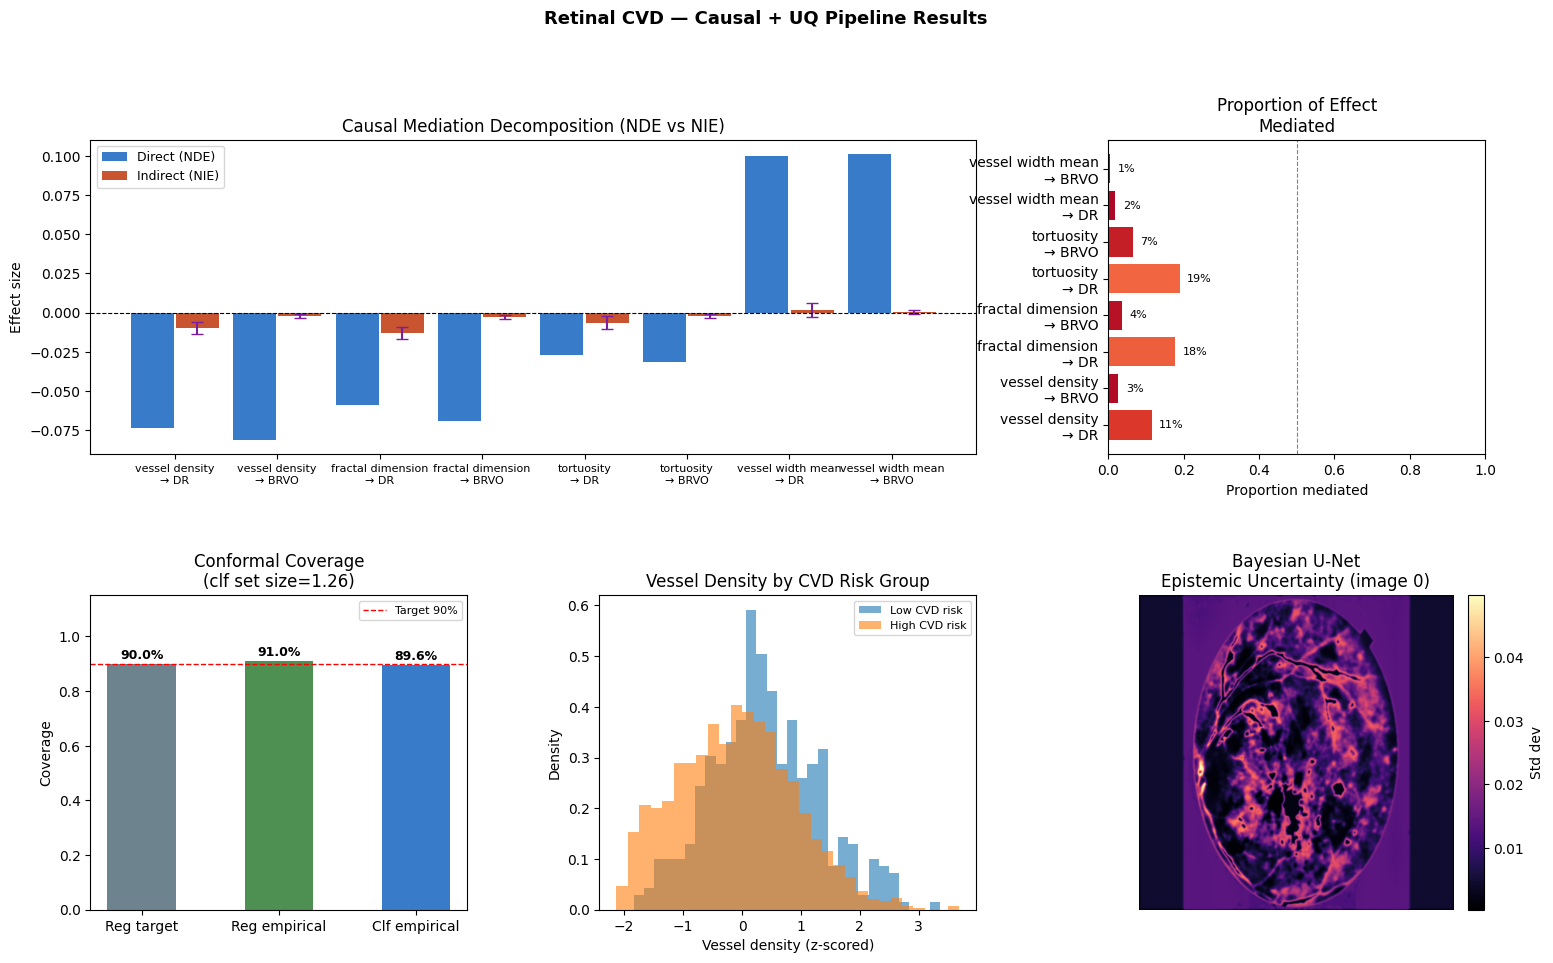

Figure saved → outputs/results_summary.png


In [16]:
# Cell 13: Plots
import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

med_df = pd.read_csv('outputs/mediation_results.csv')
feat   = pd.read_csv('outputs/features_table.csv')
unc    = np.load('outputs/uncertainty.npy')

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Retinal Disease Risk — Causal + UQ Pipeline Results',
             fontsize=13, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Mediation decomposition
ax1 = fig.add_subplot(gs[0, :2])
x   = np.arange(len(med_df))
lbs = (med_df['exposure'].str.replace('_',' ') + '\n→ ' +
       med_df['mediator'].str.replace('_',' '))
ax1.bar(x - 0.22, med_df['direct_effect'],   0.42, label='Direct (NDE)',   color='#1565C0', alpha=0.85)
ax1.bar(x + 0.22, med_df['indirect_effect'], 0.42, label='Indirect (NIE)', color='#BF360C', alpha=0.85)
if 'indirect_ci_low' in med_df.columns:
    yerr = [med_df['indirect_effect'] - med_df['indirect_ci_low'],
            med_df['indirect_ci_high'] - med_df['indirect_effect']]
    ax1.errorbar(x + 0.22, med_df['indirect_effect'],
                 yerr=yerr, fmt='none', color='#7B1FA2', capsize=4, lw=1.5)
ax1.set_xticks(x); ax1.set_xticklabels(lbs, fontsize=8)
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.set_ylabel('Effect size'); ax1.set_title('Causal Mediation Decomposition (NDE vs NIE)')
ax1.legend(fontsize=9)

# Plot 2: Proportion mediated — NaN shown as hatched "n.s." bar
ax2 = fig.add_subplot(gs[0, 2])
pm_raw  = med_df['proportion_mediated'].tolist()
pm_disp = [0.0 if (isinstance(v, float) and math.isnan(v)) else float(np.clip(v, 0, 1))
           for v in pm_raw]
colours = plt.cm.RdYlGn(pm_disp)
bars = ax2.barh(lbs.tolist(), pm_disp, color=colours)
# Hatch n.s. bars
for bar, v_raw in zip(bars, pm_raw):
    if isinstance(v_raw, float) and math.isnan(v_raw):
        bar.set_hatch('///')
        bar.set_edgecolor('#888888')
ax2.set_xlim(0, 1); ax2.set_xlabel('Proportion mediated')
ax2.set_title('Proportion of Effect\nMediated')
ax2.axvline(0.5, color='grey', ls='--', lw=0.8)
for bar, v_raw, v_disp in zip(bars, pm_raw, pm_disp):
    label = 'n.s.' if (isinstance(v_raw, float) and math.isnan(v_raw)) else f'{v_disp:.0%}'
    x_pos = max(v_disp + 0.02, 0.02)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=8)

# Plot 3: Conformal classification coverage (primary UQ metric)
ax3 = fig.add_subplot(gs[1, 0])
if clf is not None:
    target = 1 - reg.alpha
    labels_  = ['Reg target','Reg empirical','Clf empirical']
    vals_    = [target, reg.empirical_coverage, clf.empirical_coverage]
    colours_ = ['#546E7A','#2E7D32','#1565C0']
    b3 = ax3.bar(labels_, vals_, color=colours_, alpha=0.85, width=0.5)
    ax3.set_ylim(0, 1.15); ax3.set_ylabel('Coverage')
    ax3.set_title(f'Conformal Coverage\n(clf set size={clf.mean_set_size:.2f})')
    for b in b3:
        ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{b.get_height():.1%}', ha='center', fontsize=9, fontweight='bold')
    ax3.axhline(target, color='red', ls='--', lw=1, label=f'Target {target:.0%}')
    ax3.legend(fontsize=8)
else:
    target = 1 - reg.alpha
    b3 = ax3.bar(['Target','Empirical'], [target, reg.empirical_coverage],
                 color=['#546E7A','#2E7D32'], alpha=0.85, width=0.5)
    ax3.set_ylim(0, 1.12); ax3.set_ylabel('Coverage')
    ax3.set_title(f'Conformal Regression Coverage\n(width={reg.mean_width:.2f})')
    for b in b3:
        ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{b.get_height():.1%}', ha='center', fontsize=10, fontweight='bold')
    ax3.axhline(target, color='red', ls='--', lw=1)

# Plot 4: Vessel density by disease-risk group
ax4 = fig.add_subplot(gs[1, 1])
for lbl, grp in feat.groupby('cvd_label'):
    ax4.hist(grp['vessel_density'], bins=30, alpha=0.6, density=True,
             label='Disease risk = 1' if lbl == 1 else 'Disease risk = 0')
ax4.legend(fontsize=8); ax4.set_xlabel('Vessel density (z-scored)')
ax4.set_ylabel('Density'); ax4.set_title('Vessel Density by Retinal Disease Risk Group')

# Plot 5: Epistemic uncertainty map
ax5 = fig.add_subplot(gs[1, 2])
im = ax5.imshow(unc[0], cmap='magma')
ax5.set_title('Bayesian U-Net\nEpistemic Uncertainty (image 0)')
ax5.axis('off')
plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04, label='Std dev')

plt.savefig('outputs/results_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved → outputs/results_summary.png')


In [17]:
# Cell 14: Print results summary
import json, pandas as pd, os, math

med_df = pd.read_csv('outputs/mediation_results.csv')
med_df_noncircular = pd.read_csv('outputs/mediation_results_noncircular.csv')

def _json_safe(v):
    """Convert NaN/inf to None for JSON serialization."""
    if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
        return None
    return v

summary = {
    'dataset'   : 'RFMiD (1,920 images) + DRIVE-trained segmenter',
    'n_patients': len(pd.read_csv('outputs/features_table.csv')),
    'mediation' : [{k: _json_safe(v) for k, v in r.items()}
                   for r in med_df.to_dict(orient='records')],
    'mediation_noncircular': [{k: _json_safe(v) for k, v in r.items()}
                              for r in med_df_noncircular.to_dict(orient='records')],
    'conformal_regression': {
        'target_coverage'    : 1 - reg.alpha,
        'empirical_coverage' : reg.empirical_coverage,
        'mean_interval_width': reg.mean_width,
        'quantile'           : reg.quantile,
        'is_binary_outcome'  : reg.is_binary_outcome,
        'clipped_to'         : reg.clipped_to,
    },
    'conformal_classification': None if clf is None else {
        'empirical_coverage' : clf.empirical_coverage,
        'mean_set_size'      : clf.mean_set_size,
        'auroc'              : _json_safe(clf.auroc),
        'f1'                 : clf.f1,
        'coverage_by_class'  : clf.coverage_by_class,
    },
    'vessel_threshold_calibration': {
        'threshold': calib.best_threshold,
        'metric'   : calib.metric,
        'score'    : calib.best_score,
    },
}
with open('outputs/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 62)
print('  FINAL RESULTS SUMMARY')
print('=' * 62)
print(f'  Dataset  : {summary["dataset"]}')
print(f'  Patients : {summary["n_patients"]}')
print()
print('  [VESSEL THRESHOLD CALIBRATION]')
vtc = summary['vessel_threshold_calibration']
print(f'  threshold={vtc["threshold"]:.4f}  {vtc["metric"]}={vtc["score"]:.4f} (DRIVE validation)')
print()
print('  [CAUSAL MEDIATION]')
print(f'  {"Exposure":<22} {"Mediator":<18} {"NDE":>8} {"NIE":>8} {"PropMed":>8}')
print('  ' + '-' * 66)
for r in summary['mediation']:
    pm = r.get("proportion_mediated")
    pm_str = f'{pm:>8.1%}' if (pm is not None and not math.isnan(float(pm))) else '     n.s.'
    print(f'  {r["exposure"]:<22} {r["mediator"]:<18} '
          f'{r["direct_effect"]:>8.4f} {r["indirect_effect"]:>8.4f} '
          f'{pm_str}')
print()
print('  [NON-CIRCULAR MEDIATION] (mediator excluded from its own outcome)')
print(f'  {"Exposure":<22} {"Mediator":<18} {"NDE":>8} {"NIE":>8} {"PropMed":>8}')
print('  ' + '-' * 66)
for r in summary['mediation_noncircular']:
    pm = r.get("proportion_mediated")
    pm_str = f'{pm:>8.1%}' if (pm is not None and not math.isnan(float(pm))) else '     n.s.'
    print(f'  {r["exposure"]:<22} {r["mediator"]:<18} '
          f'{r["direct_effect"]:>8.4f} {r["indirect_effect"]:>8.4f} '
          f'{pm_str}')
cr = summary['conformal_regression']
tag = '  [DIAGNOSTIC ONLY -- binary outcome]' if cr['is_binary_outcome'] else ''
print()
print(f'  [CONFORMAL REGRESSION]{tag}')
print(f'  Target / empirical coverage : {cr["target_coverage"]:.0%} / {cr["empirical_coverage"]:.1%}')
print(f'  Mean interval width         : {cr["mean_interval_width"]:.4f}')
print(f'  Clipped to                  : {cr["clipped_to"]}')
if summary['conformal_classification']:
    cc = summary['conformal_classification']
    print()
    print('  [CONFORMAL CLASSIFICATION]  (headline UQ result)')
    print(f'  Empirical coverage : {cc["empirical_coverage"]:.1%}')
    print(f'  Mean set size      : {cc["mean_set_size"]:.2f}')
    print(f'  AUROC              : {cc["auroc"]}')
    print(f'  F1                 : {cc["f1"]:.4f}')
    print(f'  Coverage by class  : {cc["coverage_by_class"]}')
print()
print('  Output files:')
for fn in sorted(os.listdir('outputs')):
    sz = os.path.getsize(f'outputs/{fn}')
    print(f'    outputs/{fn}  ({sz/1024:.1f} KB)')
print('=' * 62)


  FINAL RESULTS SUMMARY
  Dataset  : RFMiD (1,920 images) + DRIVE-trained segmenter
  Patients : 1920

  [VESSEL THRESHOLD CALIBRATION]
  threshold=0.2273  dice=0.4786 (DRIVE validation)

  [CAUSAL MEDIATION]
  Exposure               Mediator                NDE      NIE  PropMed
  ------------------------------------------------------------------
  vessel_density         DR                  -0.0737  -0.0096    11.5%
  vessel_density         BRVO                -0.0810  -0.0022     2.7%
  fractal_dimension      DR                  -0.0592  -0.0128    17.7%
  fractal_dimension      BRVO                -0.0693  -0.0026     3.7%
  tortuosity             DR                  -0.0272  -0.0063    18.9%
  tortuosity             BRVO                -0.0313  -0.0022     6.6%
  vessel_width_mean      DR                   0.0999   0.0019     1.8%
  vessel_width_mean      BRVO                 0.1012   0.0006     0.6%

  [NON-CIRCULAR MEDIATION] (mediator excluded from its own outcome)
  Exposure    

## Official RFMiD Test-Set Evaluation

This is a held-out **replication of Stages 1-4 above on RFMiD's official Test split** (640 images, never touched by anything above) -- not a fifth pipeline stage. Every result so far comes from an internal re-split of the 1,920-image Training set; this section checks whether biomarker extraction, conformal coverage, and mediation hold up on genuinely unseen RFMiD images, using the SAME trained segmenter checkpoint and the SAME calibrated `vessel_threshold` (no retraining, no re-calibration).

In [18]:
# Official Test-Set Eval (a): segment + extract biomarkers on the official Test split
import yaml, numpy as np, os, torch, pandas as pd
from sklearn.preprocessing import StandardScaler

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.data.dataset        import RetinalDataset
from src.models.factory      import build_segmenter, train_segmenter
from src.features.extraction import extract_batch

print('Loading RFMiD official Test split...')
ds_test = RetinalDataset(cfg, synthetic=False, split='testing')
images_test = np.stack([ds_test[i].image for i in range(len(ds_test))])
print(f'Loaded : {len(ds_test)} images  shape={images_test.shape}')

model = build_segmenter(cfg)
model = train_segmenter(model, images_test, cfg)  # checkpoint exists -> loads, does NOT retrain
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

BATCH_SIZE = 16
MC_SAMPLES = cfg['segmentation']['mc_samples']
x = torch.tensor(images_test).permute(0, 3, 1, 2).float() / 255.0
n = x.shape[0]
masks_list, uncs_list = [], []
model.eval()
print(f'\nRunning batched MC inference on the Test split (S={MC_SAMPLES})...')
for start in range(0, n, BATCH_SIZE):
    xb  = x[start:start + BATCH_SIZE].to(device)
    out = model(xb, mc_samples=MC_SAMPLES)
    masks_list.append(out['mask'].squeeze(1).cpu().numpy())
    uncs_list.append(out['uncertainty'].squeeze(1).cpu().numpy())
    if (start // BATCH_SIZE) % 10 == 0:
        print(f'  [{start + len(masks_list[-1])}/{n}]', flush=True)
masks_test = np.concatenate(masks_list)
uncs_test  = np.concatenate(uncs_list)

feat_df_test = pd.DataFrame(extract_batch(masks_test, uncs_test, cfg))
meta_test = ds_test.metadata_frame()
df_test = pd.concat([meta_test.reset_index(drop=True),
                     feat_df_test.reset_index(drop=True)], axis=1)
df_test['cvd_risk']  = df_test['Disease_Risk'].astype(float)
df_test['cvd_label'] = df_test['Disease_Risk'].astype(int)

bio_cols = ['vessel_density','fractal_dimension','tortuosity',
            'vessel_width_mean','num_bifurcations','branching_density']
df_test[bio_cols] = StandardScaler().fit_transform(df_test[bio_cols])
df_test.to_csv('outputs/features_table_test_official.csv', index=False)
print(f'\nOfficial Test-split biomarker table: {len(df_test)} images')
print(f'Disease_Risk balance : {df_test["cvd_label"].value_counts().to_dict()}')


Loading RFMiD official Test split...


/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'age' (for 'age') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'dm_duration' (for 'diabetes_time') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'ldl_cholesterol' (for 'ldl_cholesterol') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'sex' (for 'sex') not found in metadata; it will be imputed.
  warnings.warn(
/content/retinal-cvd-causal-uq/src/data/dataset.py:103: UserWarning: Column 'systolic_bp' (for 'systolic_bp') not found in metadata; it will be imputed.
  warnings.warn(


Loaded : 640 images  shape=(640, 512, 512, 3)

Running batched MC inference on the Test split (S=20)...
  [16/640]
  [176/640]
  [336/640]
  [496/640]

Official Test-split biomarker table: 640 images
Disease_Risk balance : {1: 506, 0: 134}


In [19]:
# Official Test-Set Eval (b): conformal, fit on Training / evaluate on official Test
import pandas as pd, yaml

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.uncertainty.conformal import (split_conformal_regression,
                                       split_conformal_classification)

df_train = pd.read_csv('outputs/features_table.csv')
df_test  = pd.read_csv('outputs/features_table_test_official.csv')

BIOMARKERS = ['vessel_density','vessel_area','fractal_dimension','tortuosity',
              'num_bifurcations','vessel_width_mean','num_components',
              'longest_vessel','branching_density']
cols = [c for c in BIOMARKERS if c in df_train.columns and c in df_test.columns]
X_train = df_train[cols].to_numpy(dtype=float)
X_test_official = df_test[cols].to_numpy(dtype=float)

print('Fitting on Training, evaluating on the official Test split...')
reg_official = split_conformal_regression(
    X_train, df_train['cvd_risk'].to_numpy(float), cfg,
    X_holdout=X_test_official, y_holdout=df_test['cvd_risk'].to_numpy(float))
print(f'  [Regression]     empirical coverage: {reg_official.empirical_coverage:.1%}  '
      f'width: {reg_official.mean_width:.2f}  clipped_to: {reg_official.clipped_to}')

clf_official = None
if df_test['cvd_label'].value_counts().min() >= 5:
    clf_official = split_conformal_classification(
        X_train, df_train['cvd_label'].to_numpy(int), cfg,
        X_holdout=X_test_official, y_holdout=df_test['cvd_label'].to_numpy(int))
    print(f'  [Classification] empirical coverage: {clf_official.empirical_coverage:.1%}  '
          f'set size: {clf_official.mean_set_size:.2f}  AUROC: {clf_official.auroc:.4f}  '
          f'F1: {clf_official.f1:.4f}')
    print(f'  Coverage by class: {clf_official.coverage_by_class}')
else:
    print('  [Classification] skipped (insufficient class balance in official Test split)')


Fitting on Training, evaluating on the official Test split...


/tmp/ipykernel_9298/2975623178.py:21: UserWarning: split_conformal_regression called on a binary/near-binary outcome (<=2 unique values); consider split_conformal_classification instead. Intervals will be clipped to (0.0, 1.0).
  reg_official = split_conformal_regression(


  [Regression]     empirical coverage: 93.8%  width: 0.87  clipped_to: (0.0, 1.0)
  [Classification] empirical coverage: 94.2%  set size: 1.28  AUROC: 0.8424  F1: 0.8974
  Coverage by class: {0: 0.7761194029850746, 1: 0.9861660079051383}


In [20]:
# Official Test-Set Eval (c): mediation replication check
import pandas as pd, numpy as np, yaml, math

with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

from src.causal.mediation import run_mediation, results_to_frame

df_test = pd.read_csv('outputs/features_table_test_official.csv')

print('Running mediation on the official Test split independently (replication check)...')
med_results_test = run_mediation(df_test, cfg)
med_df_test = results_to_frame(med_results_test)
med_df_test.to_csv('outputs/mediation_results_test_official.csv', index=False)

print(f'{"Exposure":<22} {"Mediator":<18} {"NDE":>9} {"NIE":>9} {"PropMed":>9}')
print('-' * 74)
for r in med_results_test:
    pm = r.proportion_mediated
    pm_str = f'{pm:>9.1%}' if not math.isnan(pm) else '     n.s.'
    print(f'{r.exposure:<22} {r.mediator:<18} {r.direct_effect:>9.4f} '
          f'{r.indirect_effect:>9.4f} {pm_str}')

# Sign agreement with the Training-split estimates -- a quick replication signal.
med_df_train = pd.read_csv('outputs/mediation_results.csv')
merged = med_df_train.merge(med_df_test, on=['exposure', 'mediator'],
                            suffixes=('_train', '_test'))
merged['sign_agrees'] = (np.sign(merged['indirect_effect_train'])
                         == np.sign(merged['indirect_effect_test']))
print(f'\nSign agreement (Training NIE vs. official Test NIE): '
      f'{merged["sign_agrees"].sum()}/{len(merged)} pairs')


Running mediation on the official Test split independently (replication check)...
Exposure               Mediator                 NDE       NIE   PropMed
--------------------------------------------------------------------------
vessel_density         DR                   -0.0898   -0.0096      9.6%
vessel_density         BRVO                 -0.0986   -0.0008      0.8%
fractal_dimension      DR                   -0.0703   -0.0132     15.8%
fractal_dimension      BRVO                 -0.0829   -0.0006      0.7%
tortuosity             DR                   -0.0101   -0.0066      n.s.
tortuosity             BRVO                 -0.0170    0.0004      n.s.
vessel_width_mean      DR                    0.1378    0.0027      1.9%
vessel_width_mean      BRVO                  0.1399    0.0006      0.4%

Sign agreement (Training NIE vs. official Test NIE): 7/8 pairs


In [21]:
# Cell 15: Save outputs to Google Drive
import shutil, os

DRIVE_OUT = '/content/drive/MyDrive/Research Works/retinal-cvd-causal-uq'
os.makedirs(f'{DRIVE_OUT}/outputs', exist_ok=True)
os.makedirs(f'{DRIVE_OUT}/outputs/checkpoints', exist_ok=True)

# Save all outputs except large .npy arrays (~4 GB each)
for fn in os.listdir('outputs'):
    if fn.endswith('.npy'):
        continue
    src = f'outputs/{fn}'
    if os.path.isfile(src):
        shutil.copy(src, f'{DRIVE_OUT}/outputs/{fn}')

# Save DRIVE checkpoint
ckpt = 'outputs/checkpoints/drive_unet.pt'
if os.path.exists(ckpt):
    shutil.copy(ckpt, f'{DRIVE_OUT}/outputs/checkpoints/drive_unet.pt')

print(f'Saved to: {DRIVE_OUT}/outputs')
print('\nFiles:')
for fn in sorted(os.listdir(f'{DRIVE_OUT}/outputs')):
    sz = os.path.getsize(f'{DRIVE_OUT}/outputs/{fn}')
    print(f'  {fn}  ({sz/1024:.1f} KB)')
print('\nNote: masks.npy and uncertainty.npy (~4 GB each) not saved to Drive.')
print('Rerun Cell 9 to regenerate them from the saved checkpoint.')

Saved to: /content/drive/MyDrive/Research Works/retinal-cvd-causal-uq/outputs

Files:
  .gitkeep  (0.0 KB)
  checkpoints  (4.0 KB)
  features_table.csv  (653.2 KB)
  features_table_test_official.csv  (217.5 KB)
  mediation_results.csv  (1.6 KB)
  mediation_results_noncircular.csv  (1.2 KB)
  mediation_results_test_official.csv  (1.5 KB)
  pipeline_overview.png  (124.3 KB)
  results_summary.png  (446.2 KB)
  summary.json  (7.3 KB)
  threshold_calibration_curve.csv  (6.7 KB)

Note: masks.npy and uncertainty.npy (~4 GB each) not saved to Drive.
Rerun Cell 9 to regenerate them from the saved checkpoint.
